In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4.5)

# UCI Credit Default Dataset: Exploratory Data Analysis

## Project Objective
This notebook performs structured EDA and data-quality checks for credit risk modeling. The goals are to understand data structure, inspect class imbalance, evaluate feature-target relationships, and define preprocessing decisions before model development.

## 1) Dataset Overview
This section loads the dataset, standardizes column names, confirms dimensions, removes the identifier column, and documents feature groups used in later analysis.

In [94]:
# Dataset overview: load, clean names, inspect shape, and drop ID
df = pd.read_excel('data/default of credit card clients.xls', header=1)
df.columns = df.columns.str.strip()

print(f"Initial shape: {df.shape}")
if 'ID' in df.columns:
    df = df.drop(columns='ID')
    print("Dropped column: ID")

print(f"Shape after basic cleaning: {df.shape}")
df.head()

Initial shape: (30000, 25)
Dropped column: ID
Shape after basic cleaning: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [95]:
# Column names
columns = pd.DataFrame({'column': df.columns})
columns

,column
0,LIMIT_BAL
1,SEX
2,EDUCATION
3,MARRIAGE
4,AGE
5,PAY_0
6,PAY_2
7,PAY_3
8,PAY_4
9,PAY_5


### Feature groups
- **Customer profile:** `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`
- **Credit limit:** `LIMIT_BAL`
- **Repayment history (ordinal):** `PAY_0` to `PAY_6`
- **Monthly bill amounts:** `BILL_AMT1` to `BILL_AMT6`
- **Monthly payment amounts:** `PAY_AMT1` to `PAY_AMT6`

Repayment history and recent bill/payment behavior are expected to be central signals for default risk.

## 2) Data Quality and Cleaning Checks
We verify data types, summary statistics, missingness, duplicates, and category coding consistency before modeling.

In [96]:
# Data types and descriptive statistics
df.info()
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [109]:
# Missing values, duplicates, and category-coded checks
missing_counts = df.isna().sum()
print('Missing values per column:')
display(missing_counts[missing_counts > 0] if (missing_counts > 0).any() else pd.Series({'No missing values': 0}))

duplicate_rows = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_rows}')

cat_code_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_code_cols:
    if col in df.columns:
        print(f'Unique values in {col}: {sorted(df[col].dropna().unique().tolist())}')

Missing values per column:


No missing values    0
dtype: int64

Duplicate rows: 35
Unique values in SEX: [1, 2]
Unique values in EDUCATION: [0, 1, 2, 3, 4, 5, 6]
Unique values in MARRIAGE: [0, 1, 2, 3]


No missing values are observed, but 35 duplicate rows are present and should be reviewed before modeling. The categorical-coded fields contain non-standard levels (for example, `EDUCATION` includes 0, 5, 6 and `MARRIAGE` includes 0), which should be recoded or grouped consistently.

## 3) Target Variable Overview
The target distribution informs baseline difficulty and evaluation design for classification.

Class counts:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Class proportions (%):
default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


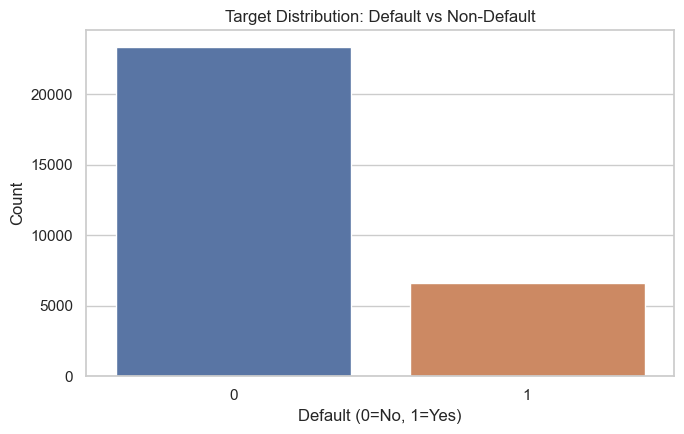

In [98]:
# Target class counts and proportions
target = 'default payment next month'

class_counts = df[target].value_counts().sort_index()
class_props = (df[target].value_counts(normalize=True).sort_index() * 100).round(2)

print('Class counts:')
print(class_counts)
print('\nClass proportions (%):')
print(class_props)

plt.figure(figsize=(7, 4.5))
sns.countplot(data=df, x=target, hue=target, palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Target Distribution: Default vs Non-Default')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Non-default observations are substantially more frequent than default observations, indicating moderate class imbalance. This should be considered when selecting evaluation metrics and validation strategy in later modeling.

## 4) Univariate Feature Exploration
This section keeps a selective set of single-variable views for credit limit, age, and key categorical-coded demographics.

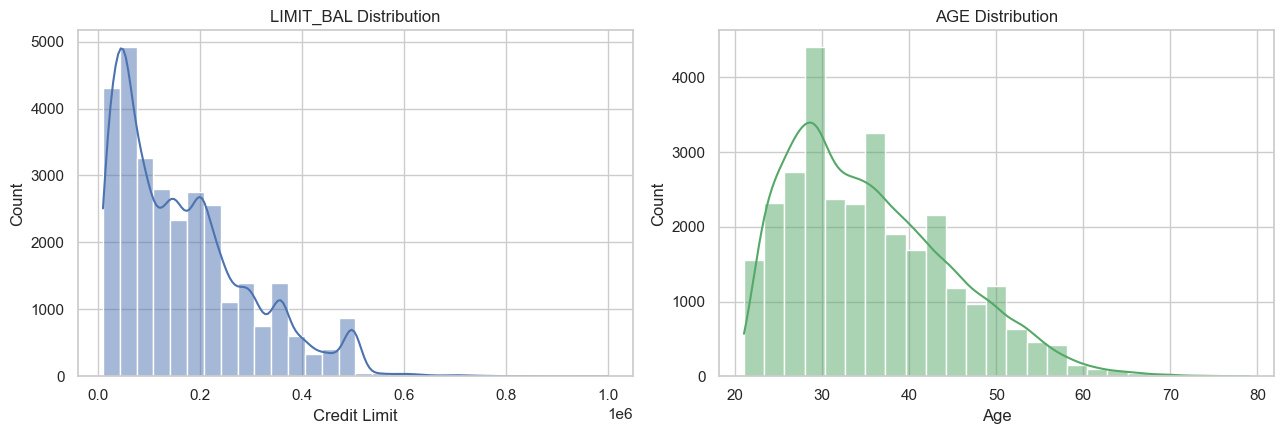

In [99]:
# Univariate distributions: LIMIT_BAL and AGE
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['LIMIT_BAL'], bins=30, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('LIMIT_BAL Distribution')
axes[0].set_xlabel('Credit Limit')
axes[0].set_ylabel('Count')

sns.histplot(df['AGE'], bins=25, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('AGE Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

`LIMIT_BAL` is right-skewed with substantial spread, while `AGE` is concentrated in middle-adult ranges. These patterns motivate robust scaling checks and potential nonlinear effects in later modeling.

### Categorical-coded demographics

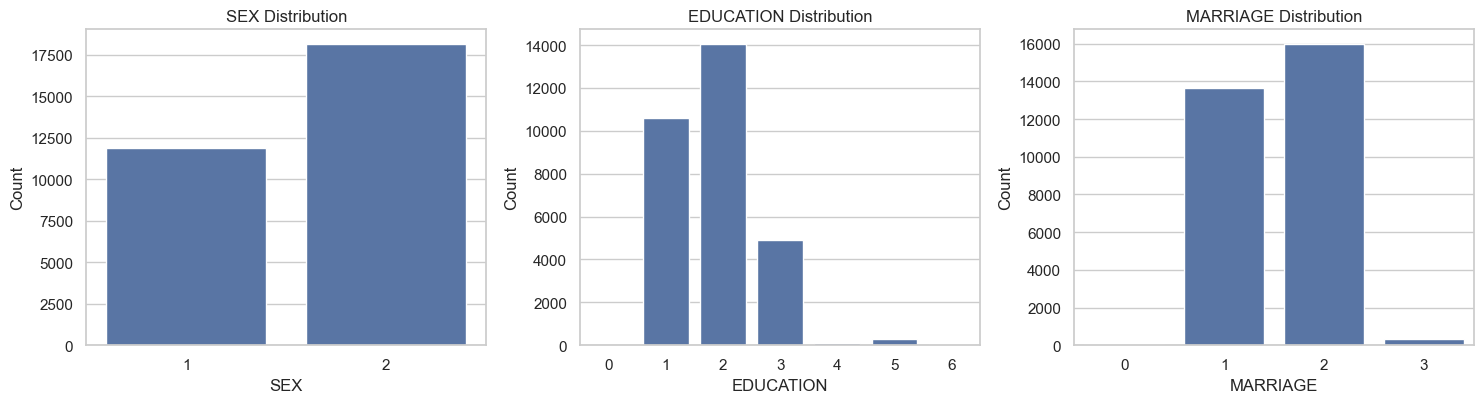

In [100]:
# Countplots for categorical-coded variables
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, col in zip(axes, cat_cols):
    if col in df.columns:
        order = sorted(df[col].dropna().unique())
        sns.countplot(data=df, x=col, order=order, ax=ax, color='#4C72B0')
        ax.set_title(f'{col} Distribution')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Demographic categories are unevenly distributed, especially for `EDUCATION` and `MARRIAGE`. Compared with repayment-history variables, these features are generally expected to provide weaker class separation on their own.

## 5) Feature vs Target Analysis
We compare key predictors against the default label to identify variables with meaningful class separation before modeling.

In [101]:
# Define target and feature groups
target = 'default payment next month'
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

pay_cols = [c for c in pay_cols if c in df.columns]
bill_cols = [c for c in bill_cols if c in df.columns]
pay_amt_cols = [c for c in pay_amt_cols if c in df.columns]

sns.set_theme(style='whitegrid', context='notebook')
palette = ['#4C72B0', '#DD8452']

print('Feature vs Target Analysis')
print(f'Target: {target}')
print(f'PAY columns: {pay_cols}')
print(f'BILL columns: {bill_cols}')
print(f'PAY_AMT columns: {pay_amt_cols}')

Feature vs Target Analysis
Target: default payment next month
PAY columns: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
BILL columns: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PAY_AMT columns: ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### `LIMIT_BAL` vs Default
We compare central tendency and distributional shape of credit limit across target classes.

LIMIT_BAL grouped summary (mean, median, std):


,mean,median,std
default_flag,,,
0,178099.73,150000.0,131628.36
1,130109.66,90000.0,115378.54


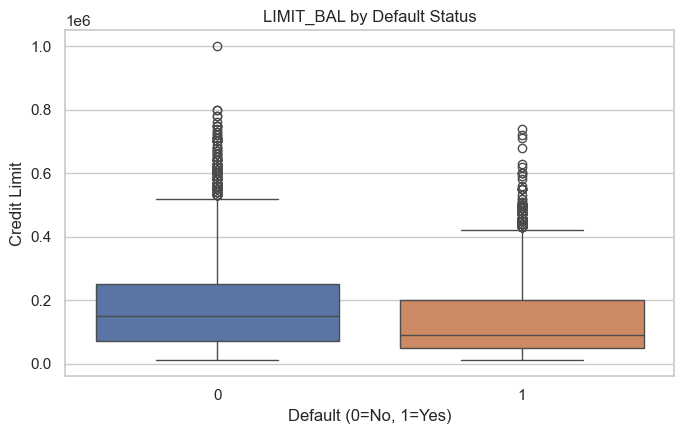

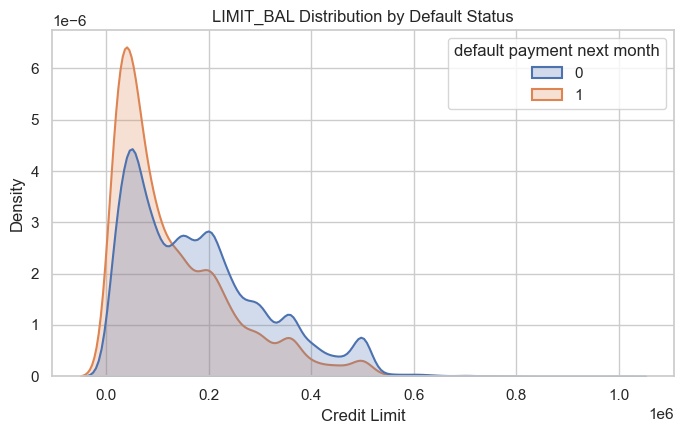

Interpretation: defaulters show lower median credit limit than non-defaulters (median gap = -60,000).


In [102]:
# LIMIT_BAL vs target: summary and visualization
limit_col = 'LIMIT_BAL'

limit_summary = (
    df.groupby(target)[limit_col]
      .agg(['mean', 'median', 'std'])
      .rename_axis('default_flag')
      .round(2)
)
print('LIMIT_BAL grouped summary (mean, median, std):')
display(limit_summary)

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x=target, y=limit_col, hue=target, palette=palette, legend=False)
plt.title('LIMIT_BAL by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Credit Limit')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
sns.kdeplot(data=df, x=limit_col, hue=target, common_norm=False, fill=True, alpha=0.25, linewidth=1.5, palette=palette)
plt.title('LIMIT_BAL Distribution by Default Status')
plt.xlabel('Credit Limit')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

limit_gap = float(limit_summary.loc[1, 'median'] - limit_summary.loc[0, 'median']) if {0, 1}.issubset(limit_summary.index) else np.nan
direction = 'lower' if limit_gap < 0 else 'higher'
print(f'Interpretation: defaulters show {direction} median credit limit than non-defaulters (median gap = {limit_gap:,.0f}).')

Defaulters have lower typical credit limits (median difference is clearly negative), while both classes show right-skewed limits and high-end outliers.

### Repayment History (`PAY_*`) vs Default
Repayment-status variables are evaluated using grouped summaries, class-split distributions, and default-rate profiles by status category.

In [103]:
# PAY_* grouped summaries by target
if pay_cols:
    pay_group_summary = (
        df.groupby(target)[pay_cols]
          .agg(['mean', 'median', 'std'])
          .round(3)
    )
    print('PAY_* grouped summary statistics by target:')
    display(pay_group_summary)
else:
    print('No PAY_* columns found.')

PAY_* grouped summary statistics by target:


PAY_0                PAY_2                PAY_3  \
                             mean median    std   mean median    std   mean   
default payment next month                                                    
0                          -0.211    0.0  0.952 -0.302    0.0  1.035 -0.316   
1                           0.668    1.0  1.383  0.458    0.0  1.502  0.362   

                                          PAY_4                PAY_5         \
                           median    std   mean median    std   mean median   
default payment next month                                                    
0                             0.0  1.048 -0.356    0.0  1.013 -0.389    0.0   
1                             0.0  1.499  0.255    0.0  1.509  0.168    0.0   

                                   PAY_6                
                              std   mean median    std  
default payment next month                              
0                           0.978 -0.406    0.0  1.006  
1                           1.483  0.112    0.0  1.486

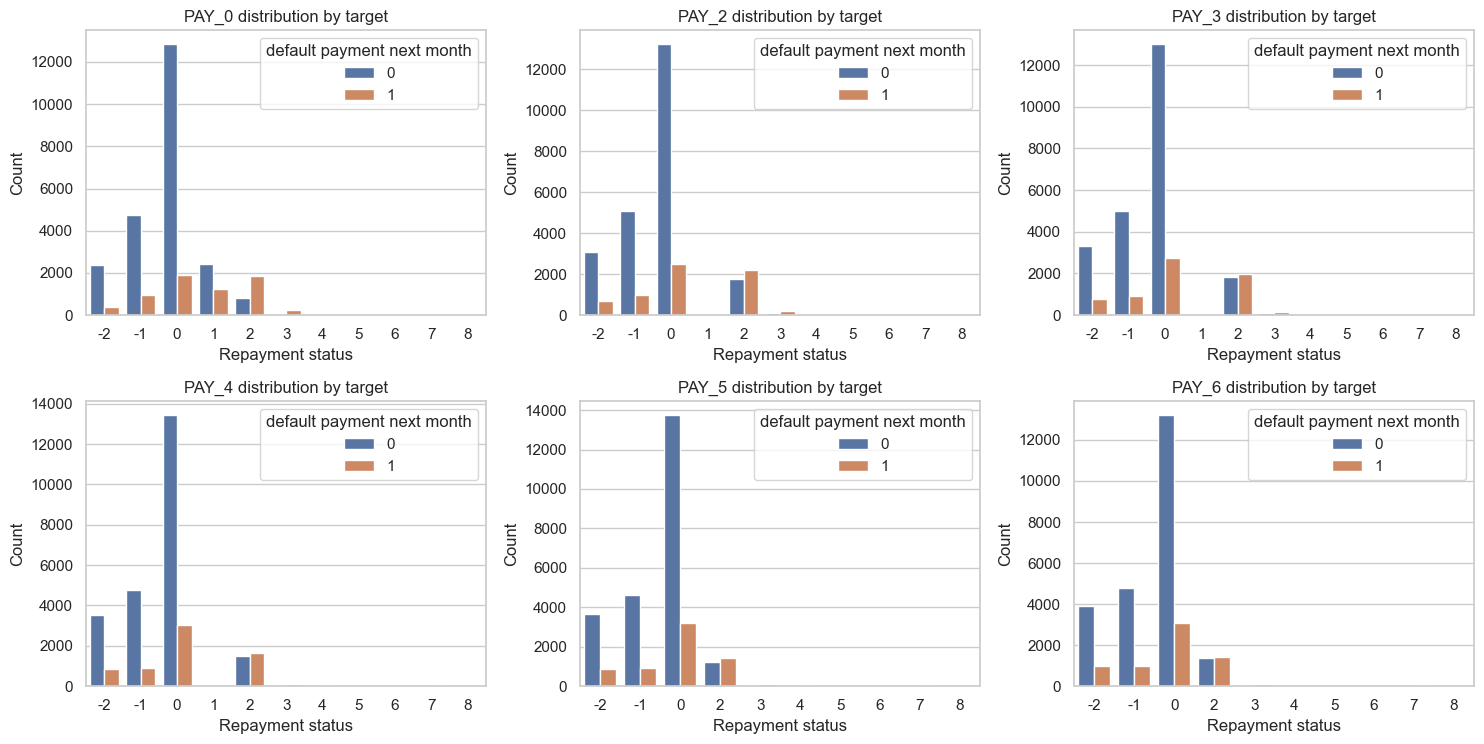

In [104]:
# PAY_* distributions split by target
if pay_cols:
    n_cols = 3
    n_rows = math.ceil(len(pay_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), squeeze=False)

    for i, col in enumerate(pay_cols):
        ax = axes[i // n_cols, i % n_cols]
        order = sorted(df[col].dropna().unique())
        sns.countplot(data=df, x=col, hue=target, order=order, palette=palette, ax=ax)
        ax.set_title(f'{col} distribution by target')
        ax.set_xlabel('Repayment status')
        ax.set_ylabel('Count')

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis('off')

    plt.tight_layout()
    plt.show()

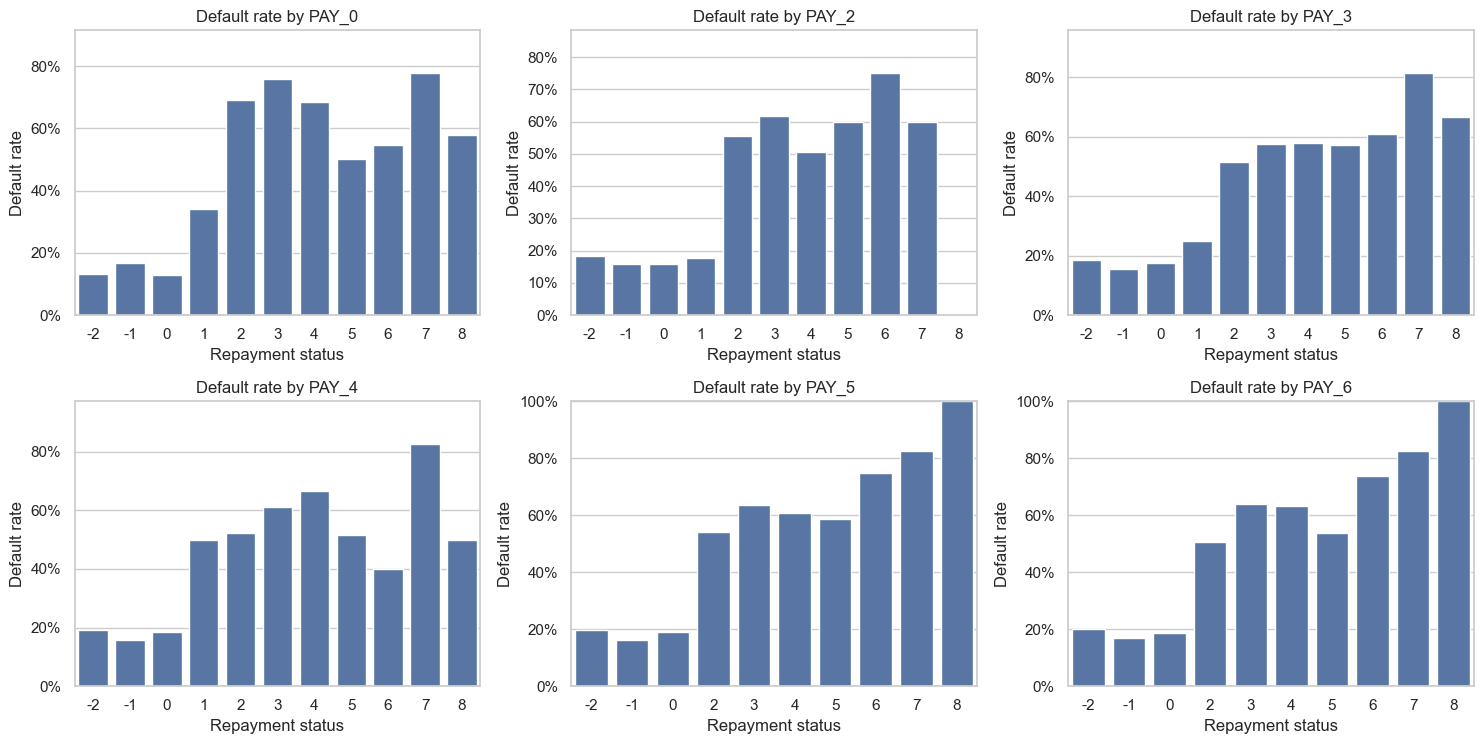

Top PAY_* features by default-rate spread:


,feature,rate_range
4,PAY_5,0.838057
5,PAY_6,0.830139
1,PAY_2,0.750000
3,PAY_4,0.668627
2,PAY_3,0.658870
0,PAY_0,0.649665


Most strongly associated with default (from these summaries): ['PAY_5', 'PAY_6', 'PAY_2']


In [105]:
# Default rate by repayment status within each PAY_* column
pay_rate_tables = {}
pay_assoc = []

if pay_cols:
    n_cols = 3
    n_rows = math.ceil(len(pay_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), squeeze=False)

    for i, col in enumerate(pay_cols):
        rates = (
            df.groupby(col, dropna=False)[target]
              .mean()
              .reset_index(name='default_rate')
              .sort_values(col)
        )
        pay_rate_tables[col] = rates

        ax = axes[i // n_cols, i % n_cols]
        sns.barplot(data=rates, x=col, y='default_rate', ax=ax)
        ax.set_title(f'Default rate by {col}')
        ax.set_xlabel('Repayment status')
        ax.set_ylabel('Default rate')
        ax.set_ylim(0, min(1, rates['default_rate'].max() * 1.15 + 0.02))
        ax.yaxis.set_major_formatter(PercentFormatter(1))

        assoc_strength = rates['default_rate'].max() - rates['default_rate'].min()
        pay_assoc.append((col, assoc_strength))

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis('off')

    plt.tight_layout()
    plt.show()

    pay_strength = pd.DataFrame(pay_assoc, columns=['feature', 'rate_range']).sort_values('rate_range', ascending=False)
    print('Top PAY_* features by default-rate spread:')
    display(pay_strength)
    top_features = pay_strength['feature'].head(3).tolist()
    print(f'Most strongly associated with default (from these summaries): {top_features}')

Repayment-history variables show strong class separation. Higher delinquency statuses map to sharply higher default rates, and the strongest spreads are concentrated in recent repayment indicators.

### Bill Amounts (`BILL_AMT1`–`BILL_AMT6`) vs Default
We compare grouped statistics and class-wise boxplots across monthly bill amounts.

BILL_AMT* grouped summary statistics by target:


BILL_AMT1                    BILL_AMT2           \
                                mean   median       std      mean   median   
default payment next month                                                   
0                           51994.23  23119.5  73577.61  49717.44  21660.5   
1                           48509.16  20185.0  73782.07  47283.62  20300.5   

                                     BILL_AMT3                    BILL_AMT4  \
                                 std      mean   median       std      mean   
default payment next month                                                    
0                           71029.95  47533.37  20202.5  69576.66  43611.17   
1                           71651.03  45181.60  19834.5  68516.98  42036.95   

                                              BILL_AMT5                     \
                             median       std      mean   median       std   
default payment next month                                                   
0                           19000.0  64324.80  40530.45  17998.0  60617.27   
1                           19119.5  64351.08  39540.19  18478.5  61424.70   

                           BILL_AMT6                     
                                mean   median       std  
default payment next month                               
0                           39042.27  16679.0  59547.02  
1                           38271.44  18028.5  59579.67

BILL_AMT* mean/median table by target:


BILL_AMT1          BILL_AMT2          BILL_AMT3  \
                                mean   median      mean   median      mean   
default payment next month                                                   
0                           51994.23  23119.5  49717.44  21660.5  47533.37   
1                           48509.16  20185.0  47283.62  20300.5  45181.60   

                                    BILL_AMT4          BILL_AMT5           \
                             median      mean   median      mean   median   
default payment next month                                                  
0                           20202.5  43611.17  19000.0  40530.45  17998.0   
1                           19834.5  42036.95  19119.5  39540.19  18478.5   

                           BILL_AMT6           
                                mean   median  
default payment next month                     
0                           39042.27  16679.0  
1                           38271.44  18028.5

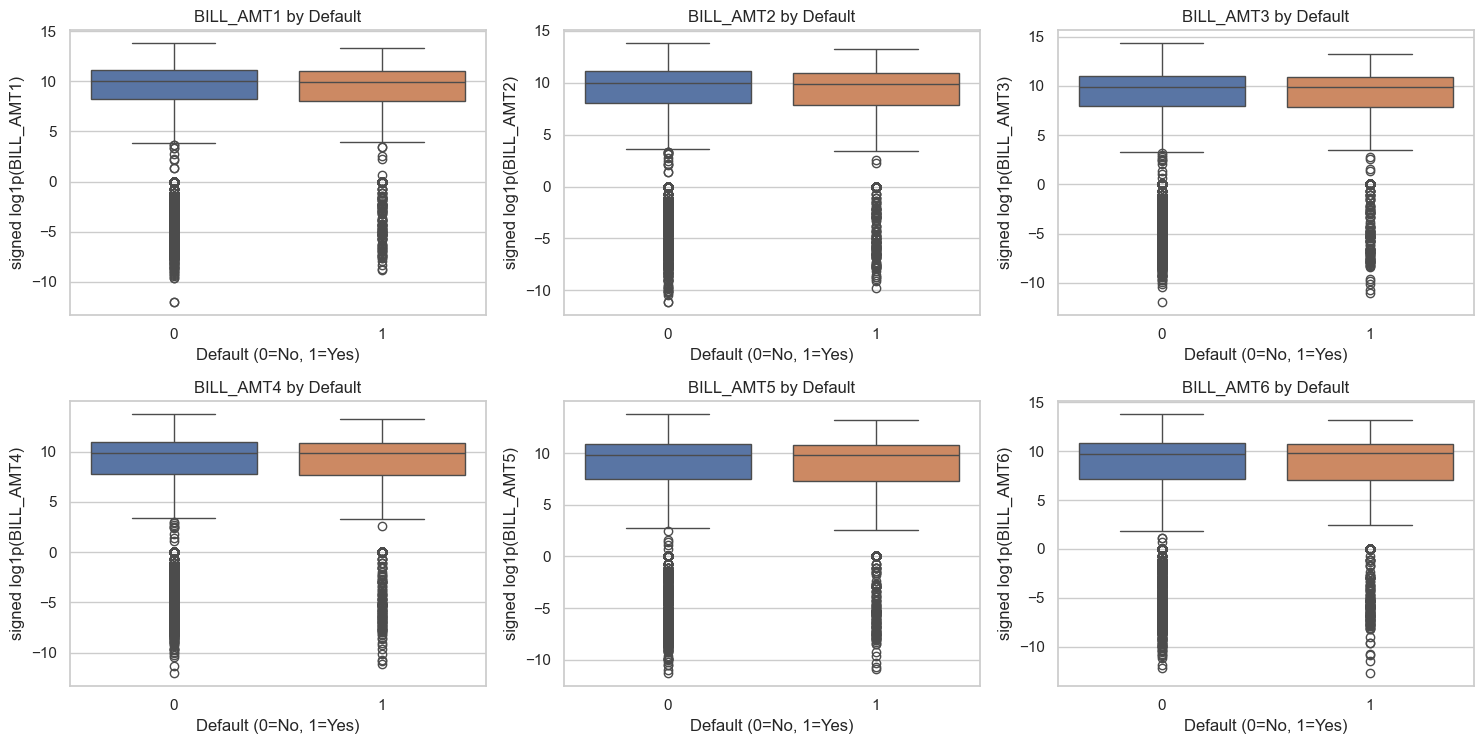

Interpretation: defaulters tend to have lower typical bill amounts overall (average median gap across BILL_AMT* = -452).
Visualization mode by column: {'BILL_AMT1': 'signed_log1p', 'BILL_AMT2': 'signed_log1p', 'BILL_AMT3': 'signed_log1p', 'BILL_AMT4': 'signed_log1p', 'BILL_AMT5': 'signed_log1p', 'BILL_AMT6': 'signed_log1p'}


In [106]:
# BILL_AMT* vs target: summaries and boxplots (with skew-safe visualization)
def signed_log1p(s):
    return np.sign(s) * np.log1p(np.abs(s))

if bill_cols:
    bill_group_summary = (
        df.groupby(target)[bill_cols]
          .agg(['mean', 'median', 'std'])
          .round(2)
    )
    print('BILL_AMT* grouped summary statistics by target:')
    display(bill_group_summary)

    bill_mean_median = (
        df.groupby(target)[bill_cols]
          .agg(['mean', 'median'])
          .round(2)
    )
    print('BILL_AMT* mean/median table by target:')
    display(bill_mean_median)

    n_cols = 3
    n_rows = math.ceil(len(bill_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), squeeze=False)

    bill_plot_mode = {}
    for i, col in enumerate(bill_cols):
        ax = axes[i // n_cols, i % n_cols]
        skew_val = df[col].dropna().skew()

        if np.isfinite(skew_val) and abs(skew_val) > 2:
            temp_plot = pd.DataFrame({target: df[target], f'{col}_plot': signed_log1p(df[col])})
            sns.boxplot(data=temp_plot, x=target, y=f'{col}_plot', hue=target, palette=palette, legend=False, ax=ax)
            ax.set_ylabel(f'signed log1p({col})')
            bill_plot_mode[col] = 'signed_log1p'
        else:
            sns.boxplot(data=df, x=target, y=col, hue=target, palette=palette, legend=False, ax=ax)
            ax.set_ylabel(col)
            bill_plot_mode[col] = 'raw'

        ax.set_title(f'{col} by Default')
        ax.set_xlabel('Default (0=No, 1=Yes)')

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis('off')

    plt.tight_layout()
    plt.show()

    bill_diff = (df[df[target] == 1][bill_cols].median() - df[df[target] == 0][bill_cols].median()).mean()
    bill_direction = 'higher' if bill_diff > 0 else 'lower'
    print(f'Interpretation: defaulters tend to have {bill_direction} typical bill amounts overall (average median gap across BILL_AMT* = {bill_diff:,.0f}).')
    print('Visualization mode by column:', bill_plot_mode)

Bill amount differences by class are present but modest relative to repayment history; distributions are heavily skewed, so log-scaled visualization is appropriate.

### Payment Amounts (`PAY_AMT1`–`PAY_AMT6`) vs Default
We compare grouped statistics and class-wise boxplots for monthly repayment amounts.

PAY_AMT* grouped summary statistics by target:


PAY_AMT1                   PAY_AMT2          \
                               mean  median       std     mean  median   
default payment next month                                               
0                           6307.34  2459.5  18014.51  6640.47  2247.5   
1                           3397.04  1636.0   9544.25  3388.65  1533.5   

                                     PAY_AMT3                   PAY_AMT4  \
                                 std     mean  median       std     mean   
default payment next month                                                 
0                           25302.26  5753.50  2000.0  18684.26  5300.53   
1                           11737.99  3367.35  1222.0  12959.62  3155.63   

                                             PAY_AMT5                    \
                            median       std     mean  median       std   
default payment next month                                                
0                           1734.0  16689.78  5248.22  1765.0  16071.67   
1                           1000.0  11191.97  3219.14  1000.0  11944.73   

                           PAY_AMT6                    
                               mean  median       std  
default payment next month                             
0                           5719.37  1706.0  18792.95  
1                           3441.48  1000.0  13464.01

PAY_AMT* mean/median table by target:


PAY_AMT1         PAY_AMT2         PAY_AMT3          \
                               mean  median     mean  median     mean  median   
default payment next month                                                      
0                           6307.34  2459.5  6640.47  2247.5  5753.50  2000.0   
1                           3397.04  1636.0  3388.65  1533.5  3367.35  1222.0   

                           PAY_AMT4         PAY_AMT5         PAY_AMT6          
                               mean  median     mean  median     mean  median  
default payment next month                                                     
0                           5300.53  1734.0  5248.22  1765.0  5719.37  1706.0  
1                           3155.63  1000.0  3219.14  1000.0  3441.48  1000.0

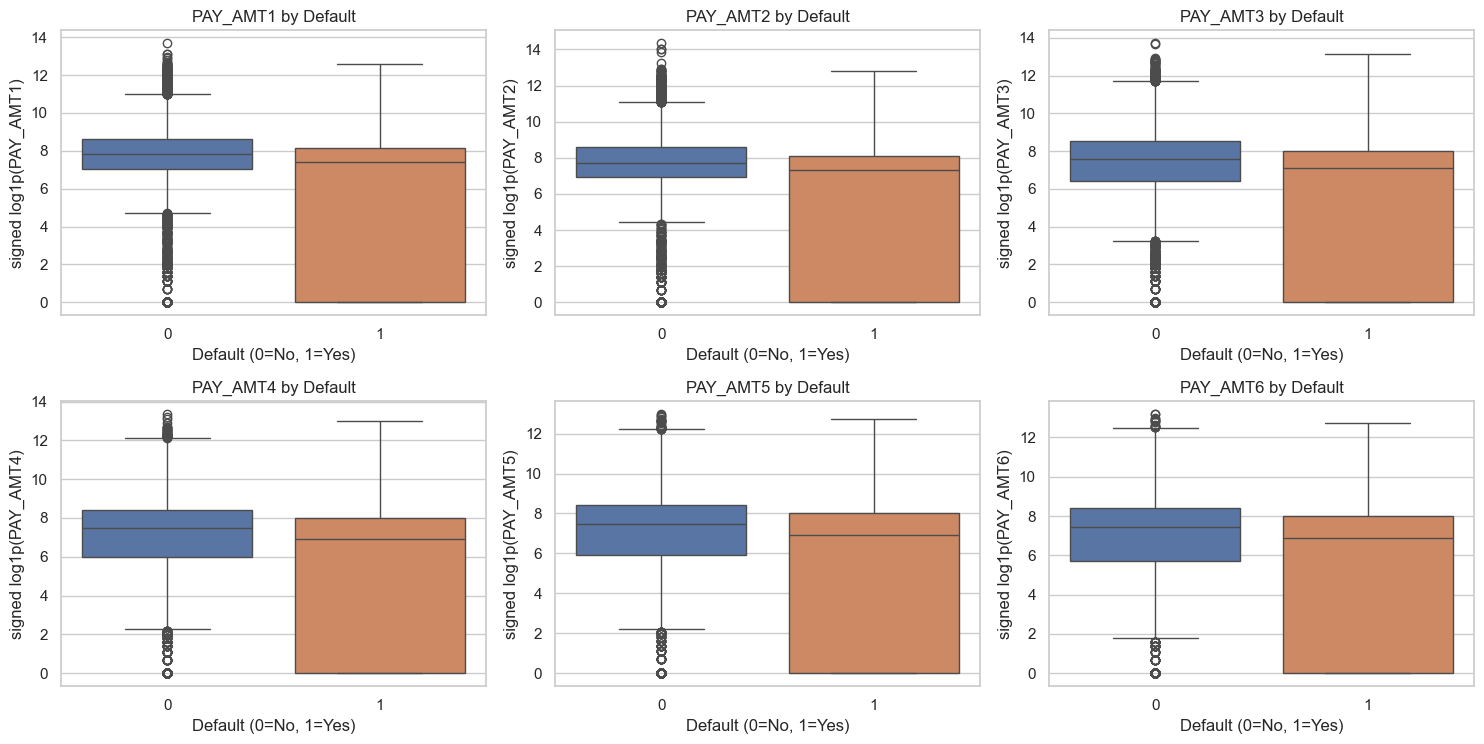

Interpretation: defaulters tend to make smaller typical payments overall (average median gap across PAY_AMT* = -753).
Visualization mode by column: {'PAY_AMT1': 'signed_log1p', 'PAY_AMT2': 'signed_log1p', 'PAY_AMT3': 'signed_log1p', 'PAY_AMT4': 'signed_log1p', 'PAY_AMT5': 'signed_log1p', 'PAY_AMT6': 'signed_log1p'}


In [107]:
# PAY_AMT* vs target: summaries and boxplots (with skew-safe visualization)
if pay_amt_cols:
    pay_amt_group_summary = (
        df.groupby(target)[pay_amt_cols]
          .agg(['mean', 'median', 'std'])
          .round(2)
    )
    print('PAY_AMT* grouped summary statistics by target:')
    display(pay_amt_group_summary)

    pay_amt_mean_median = (
        df.groupby(target)[pay_amt_cols]
          .agg(['mean', 'median'])
          .round(2)
    )
    print('PAY_AMT* mean/median table by target:')
    display(pay_amt_mean_median)

    n_cols = 3
    n_rows = math.ceil(len(pay_amt_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), squeeze=False)

    pay_amt_plot_mode = {}
    for i, col in enumerate(pay_amt_cols):
        ax = axes[i // n_cols, i % n_cols]
        skew_val = df[col].dropna().skew()

        if np.isfinite(skew_val) and abs(skew_val) > 2:
            temp_plot = pd.DataFrame({target: df[target], f'{col}_plot': signed_log1p(df[col])})
            sns.boxplot(data=temp_plot, x=target, y=f'{col}_plot', hue=target, palette=palette, legend=False, ax=ax)
            ax.set_ylabel(f'signed log1p({col})')
            pay_amt_plot_mode[col] = 'signed_log1p'
        else:
            sns.boxplot(data=df, x=target, y=col, hue=target, palette=palette, legend=False, ax=ax)
            ax.set_ylabel(col)
            pay_amt_plot_mode[col] = 'raw'

        ax.set_title(f'{col} by Default')
        ax.set_xlabel('Default (0=No, 1=Yes)')

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis('off')

    plt.tight_layout()
    plt.show()

    pay_amt_diff = (df[df[target] == 1][pay_amt_cols].median() - df[df[target] == 0][pay_amt_cols].median()).mean()
    pay_amt_direction = 'smaller' if pay_amt_diff < 0 else 'larger'
    print(f'Interpretation: defaulters tend to make {pay_amt_direction} typical payments overall (average median gap across PAY_AMT* = {pay_amt_diff:,.0f}).')
    print('Visualization mode by column:', pay_amt_plot_mode)

Defaulters consistently make smaller median payments across months, supporting the view that weaker repayment behavior is a key risk signal.

## 6) Correlation and Redundancy
A correlation view helps identify repeated monthly variables that may carry overlapping information.

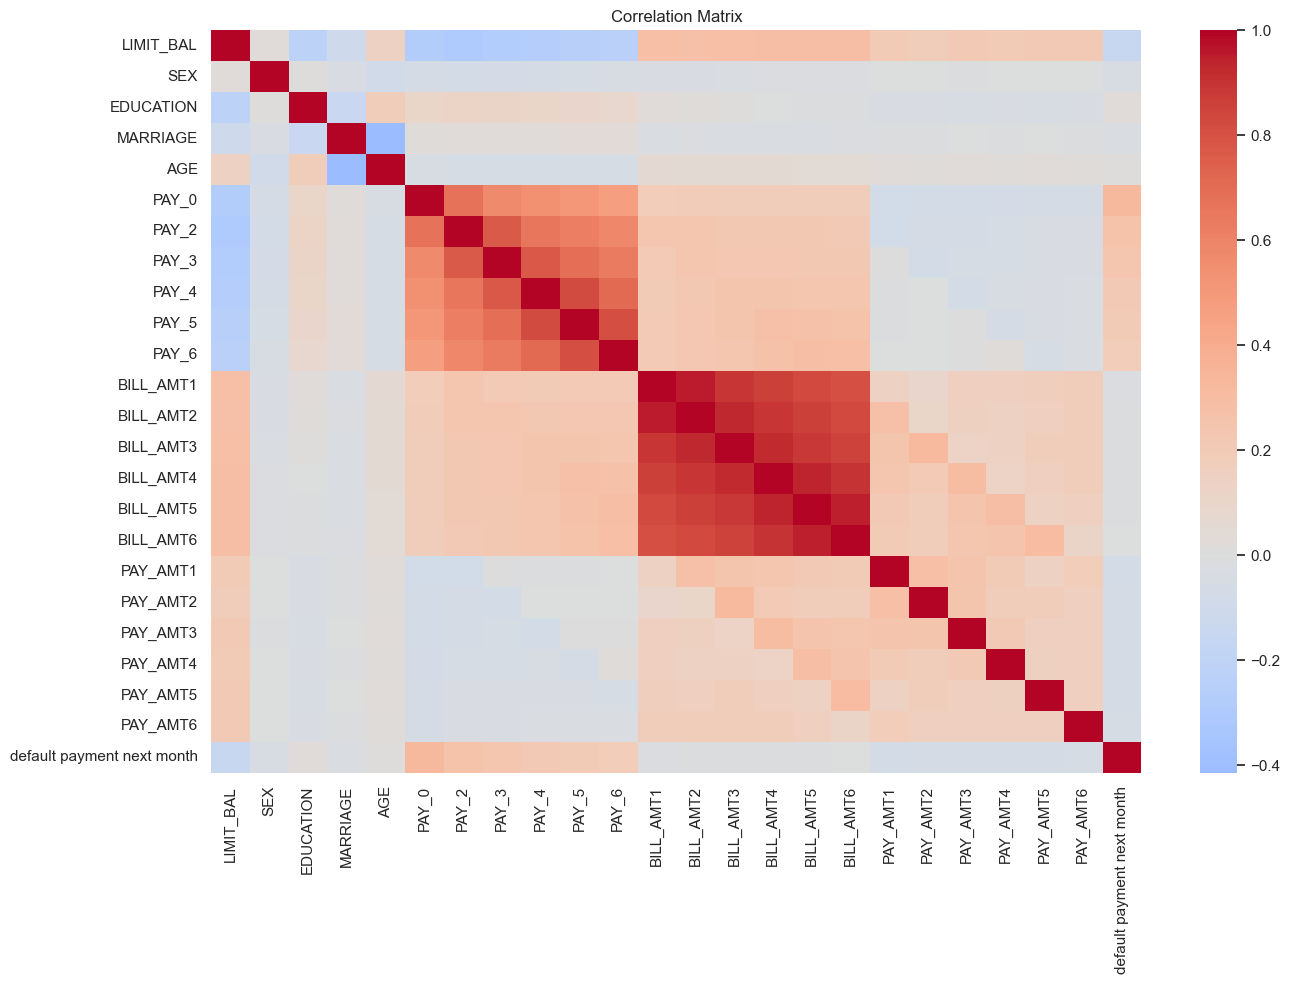

In [108]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Repeated monthly bill and payment variables are visibly correlated across adjacent months, indicating potential redundancy and possible multicollinearity in modeling pipelines.

## 7) EDA Summary and Next-Step Cleaning Decisions
### EDA Summary
- The target is moderately imbalanced, with non-default cases more common than default cases.
- Repayment-history features (`PAY_*`) show the clearest separation between classes and strongest default-rate gradients.
- Defaulters tend to have lower credit limits and lower monthly payment amounts.
- Bill/payment monthly blocks are internally correlated and likely contain overlapping signal.

### Preprocessing Decisions for Modeling
- Keep `ID` removed.
- Treat `SEX`, `EDUCATION`, and `MARRIAGE` as categorical-coded features.
- Treat `PAY_*` as ordinal repayment-status variables.
- Consider scaling continuous features for models sensitive to feature scale.
- Monitor multicollinearity among `BILL_AMT*` and `PAY_AMT*` monthly variables.
- Address class imbalance in model evaluation (for example, stratified validation and imbalance-aware metrics).

In [111]:
# Remove duplicates before saving
df_to_save = df.copy()

if 'ID' in df_to_save.columns:
    df_to_save = df_to_save.drop(columns=['ID'])

# Drop duplicate rows
df_to_save = df_to_save.drop_duplicates()

df_to_save.to_csv('data/credit_data.csv', index=False)

print("Saved cleaned dataset as 'credit_data.csv'")
print("Shape after removing duplicates:", df_to_save.shape)

Saved cleaned dataset as 'credit_data.csv'
Shape after removing duplicates: (29965, 24)
